# Spotify Exploratory Data Analysis (EDA)

## EDA for Baseline Model

### 1. Setup & Data Loading 

#### 1.1 Path Configuration 

If you followed the README correctly, the path configuration should be correct and you should have the following datasets required in `/data/cleaned/` or `/data/processed/` (_local_) **OR** `/kaggle/working/` (_kaggle_).

In [1]:
import os

# Configure data paths
SPOTIFY_VIRAL = "spotify_tracks_viral.parquet"
SPOTIFY_DROPPED = "spotify_tracks_dropped.parquet"
SPOTIFY_BASELINE = "spotify_tracks_baseline.parquet"
SPOTIFY_RAW = "spotify_tracks.csv"
SPOTIFY_CLEANED = "spotify_tracks_cleaned.csv"

# Detect is running on Kaggle environment
IS_KAGGLE = os.path.exists('/kaggle/working/')

# Set input and output paths
if IS_KAGGLE:
    DATA_PATH = '/kaggle/working/'
    OUTPUT_PATH = '/kaggle/working/'
else:
    PROCESSED_DATA_PATH = '../data/processed/'
    RAW_DATA_PATH = '../data/raw/'
    CLEANED_DATA_PATH = '../data/cleaned/'

#### 1.2 Import Packages

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import argparse

from __future__ import annotations

### 2. EDA on Spotify Tracks with Viral Target

#### 2.1 Data Loading 

In [3]:
df = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, SPOTIFY_VIRAL))

#### 2.2 Data Inspection

In [4]:
shape = df.shape
print(f"Shape of the dataset: {shape}")

Shape of the dataset: (113999, 22)


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 113999 entries, 0 to 113998
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        113999 non-null  int64  
 1   track_id          113999 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        113999 non-null  int64  
 6   duration_ms       113999 non-null  int64  
 7   explicit          113999 non-null  bool   
 8   danceability      113999 non-null  float64
 9   energy            113999 non-null  float64
 10  key               113999 non-null  int64  
 11  loudness          113999 non-null  float64
 12  mode              113999 non-null  int64  
 13  speechiness       113999 non-null  float64
 14  acousticness      113999 non-null  float64
 15  instrumentalness  113999 non-null  float64
 16  liveness          113999 non-nu

#### 2.3 Artist with Most Number of Tracks

In [6]:
df_artist = df.groupby(['artists']).size().rename("count").to_frame()
df_artist.sort_values(by="count", ascending=False)

,count
artists,
the beatles,279
george jones,271
stevie wonder,236
linkin park,224
ella fitzgerald,222
...,...
misty in roots,1
drew holcomb;ellie holcomb;drew holcomb & the neighbors,1
mitchell tenpenny,1


#### 2.4 Genre with Most Number of Tracks

In [7]:
df_genre = df.groupby(['track_genre']).size().rename("count").to_frame()
df_genre.sort_values(by="count", ascending=False)

,count
track_genre,
acoustic,1000
afrobeat,1000
psych-rock,1000
progressive-house,1000
power-pop,1000
...,...
emo,1000
electronic,1000
electro,1000


#### 2.5 Popularity Distribution

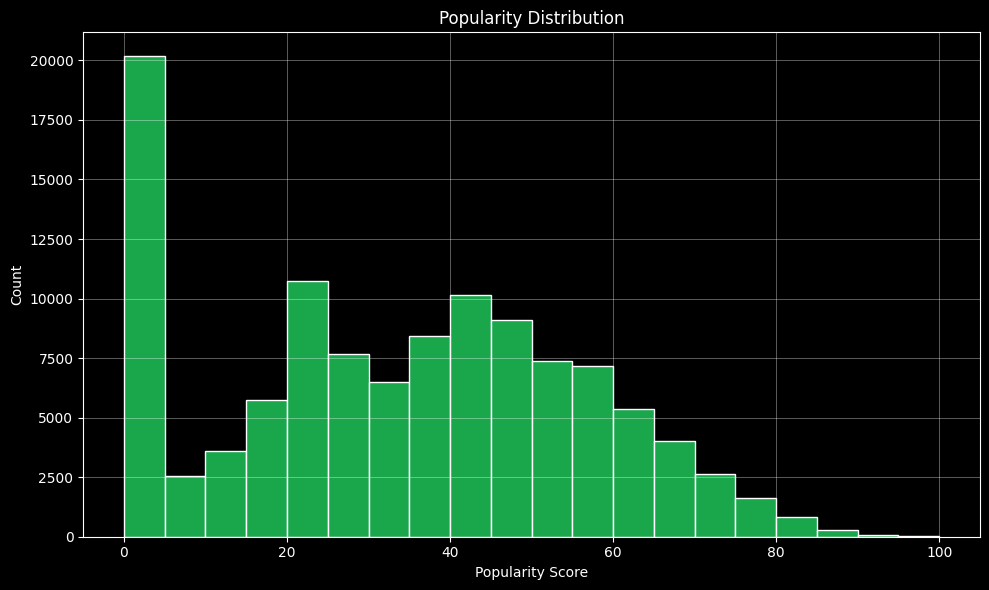

In [8]:
SPOTIFY_GREEN = "#1DB954"

plt.style.use("dark_background")  # Spotify-like dark UI

plt.figure(figsize=(10, 6))
sns.histplot(
    df["popularity"],
    bins=20,
    kde=False,
    color=SPOTIFY_GREEN,
    edgecolor="white",
    alpha=0.9
)

plt.title("Popularity Distribution", color="white")
plt.xlabel("Popularity Score", color="white")
plt.ylabel("Count", color="white")
plt.tick_params(axis="x", colors="white")
plt.tick_params(axis="y", colors="white")

# Soften grid lines on dark background
ax = plt.gca()
ax.grid(False)  # remove default grid
ax.grid(True, color="#ffffff", alpha=0.5, linewidth=0.5)  # custom, less bright grid

plt.tight_layout()
plt.show()

#### 2.6 Virality Rate by Genre

In [9]:
genre_virality = (
    df.groupby('track_genre')['viral']
    .mean()
    .sort_values(ascending=False)
)

top_genres = (
    df['track_genre']
    .value_counts()
    .head(20)
    .index
)

df_top = df[df['track_genre'].isin(top_genres)]

genre_virality = (
    df_top.groupby('track_genre')['viral']
    .mean()
    .sort_values(ascending=False)
    
)

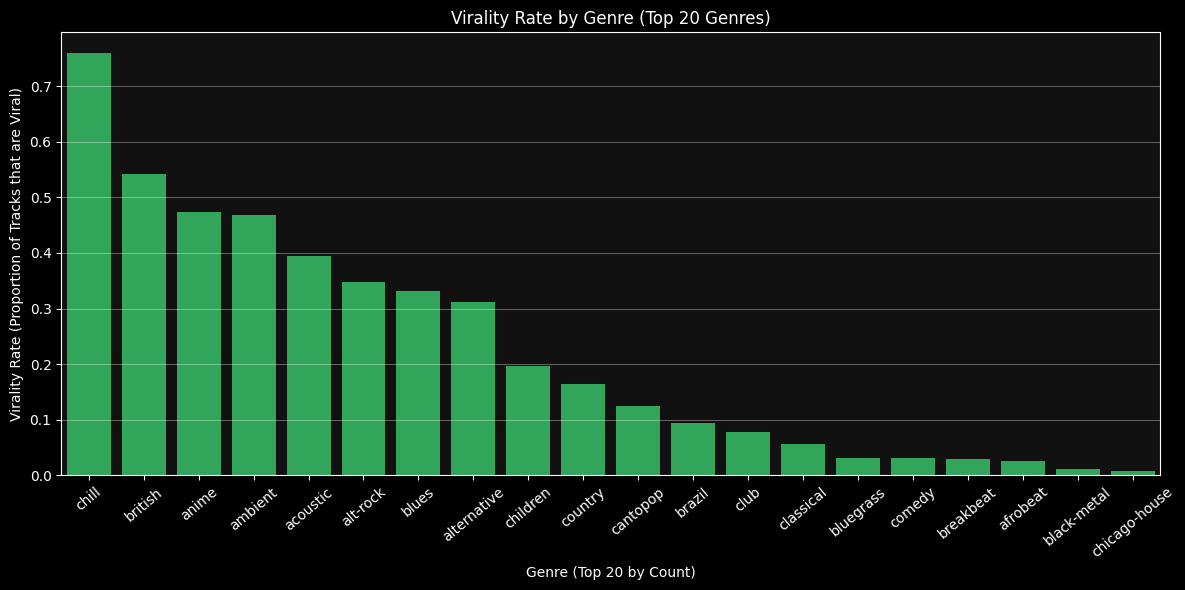

In [10]:
SPOTIFY_GREEN = "#1DB954"

plt.style.use("dark_background")  # match the other plots

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=genre_virality.index,
    y=genre_virality.values,
    color=SPOTIFY_GREEN,
)

# Text colors
ax.set_title("Virality Rate by Genre (Top 20 Genres)", color="white")
ax.set_xlabel("Genre (Top 20 by Count)", color="white")
ax.set_ylabel("Virality Rate (Proportion of Tracks that are Viral)", color="white")
ax.tick_params(axis="x", colors="white", rotation=40)
ax.tick_params(axis="y", colors="white")

# Softer grid on dark background
ax.grid(False)  # remove default
ax.grid(True, axis="y", color="#ffffff", alpha=0.5, linewidth=0.5)

# Dark axes face (optional, for extra contrast)
ax.set_facecolor("#111111")

plt.tight_layout()
plt.show()

#### 2.7 Stack Bar Counts (Viral vs. Non-Viral Per Genre)

This graph only shows the Top 20 Genres by total count.

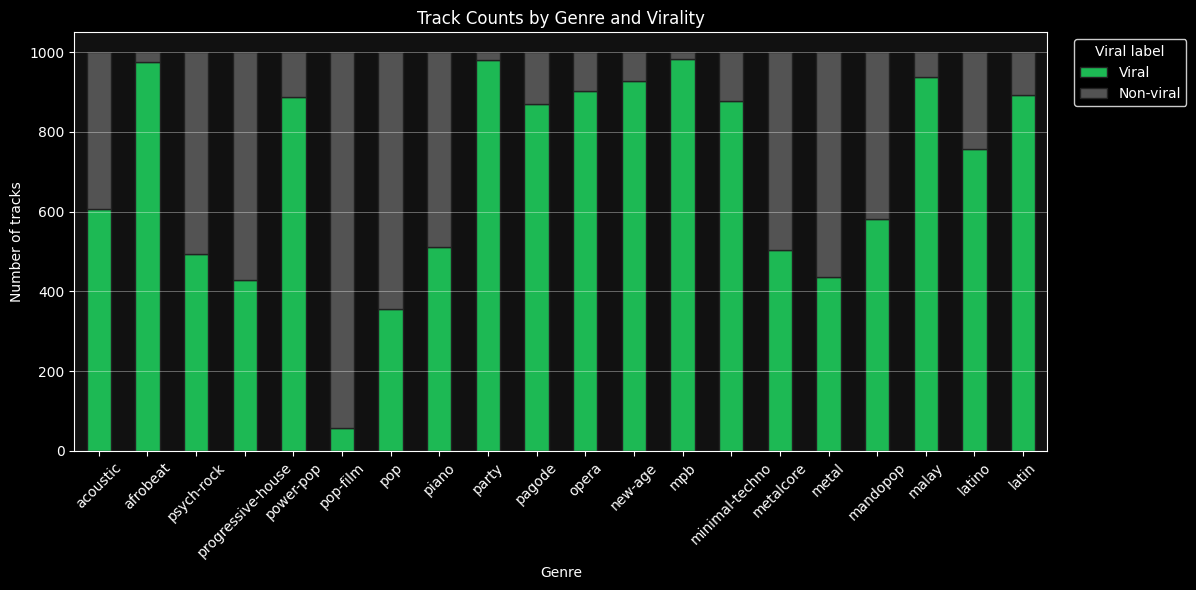

In [11]:
# Build counts table: genres × viral flag
genre_viral_counts = pd.crosstab(df["track_genre"], df["viral"])

# Optional: restrict to top 20 genres by total count
top_genres = (
    genre_viral_counts.sum(axis=1)
    .sort_values(ascending=False)
    .head(20)
    .index
)
genre_viral_counts = genre_viral_counts.loc[top_genres]

# Nicer column labels for legend
genre_viral_counts.columns = ["Viral", "Non-viral"]

# Plot stacked bar chart with dark background
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(12, 6))

genre_viral_counts.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#1DB954", "#535353"],
    edgecolor="#222222"  # softer edges (optional)
)

ax.set_xlabel("Genre", color="white")
ax.set_ylabel("Number of tracks", color="white")
ax.set_title("Track Counts by Genre and Virality", color="white")
ax.tick_params(axis="x", colors="white", rotation=45)
ax.tick_params(axis="y", colors="white")

# Softer grid on dark background
ax.grid(False)  # remove default
ax.grid(True, axis="y", color="#ffffff", alpha=0.5, linewidth=0.5)

# Move legend out of the middle
legend = ax.legend(
    title="Viral label",
    loc="upper right",
    bbox_to_anchor=(1.15, 1.0),
    frameon=True
)
plt.setp(legend.get_texts(), color="white")
legend.get_title().set_color("white")
legend.get_frame().set_edgecolor("white")

ax.set_facecolor("#111111")
fig.patch.set_facecolor("#000000")

plt.tight_layout()
plt.show()

#### 2.8 Distribution of Key Audio Features

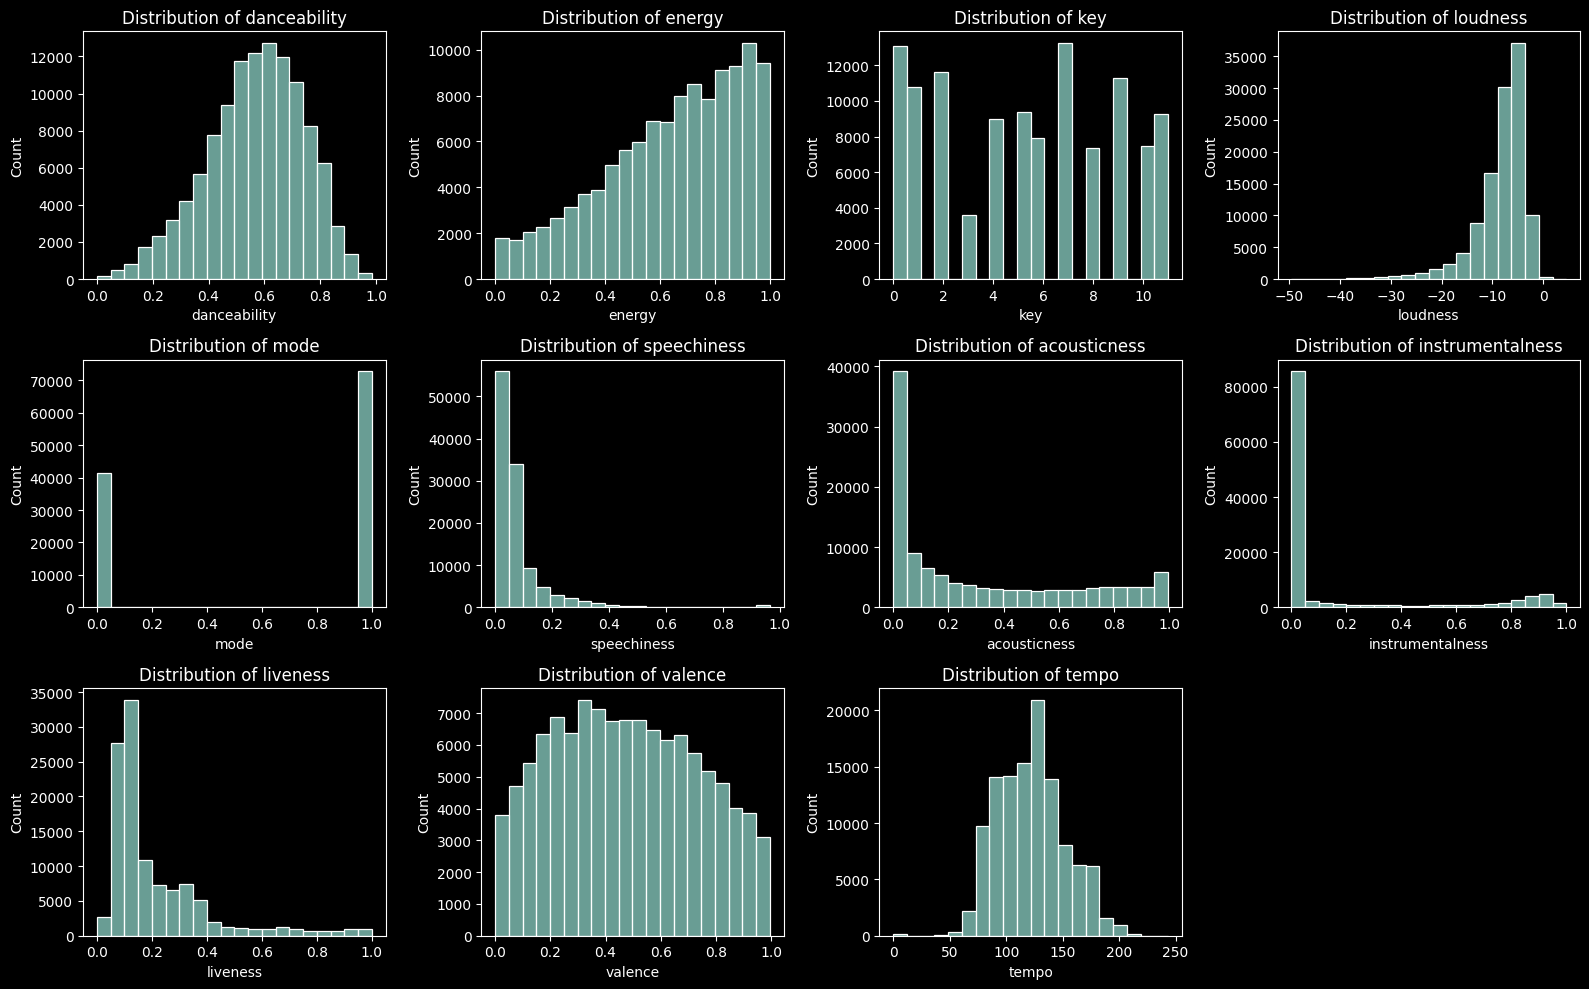

In [12]:
audio_features = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

# Create subplots for each audio feature
n_rows, m_cols = 3, 4
fig, axes = plt.subplots(n_rows, m_cols, figsize=(16, 10))
axes = axes.flatten()

# Plot each audio feature
for i, feature in enumerate(audio_features):
    ax = axes[i]
    sns.histplot(df[feature], bins=20, kde=False, ax=ax)
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')

# Hide any unused subplots (if features < n_rows * m_cols)
for j in range(len(audio_features), n_rows * m_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### 2.9 Correlation Analysis

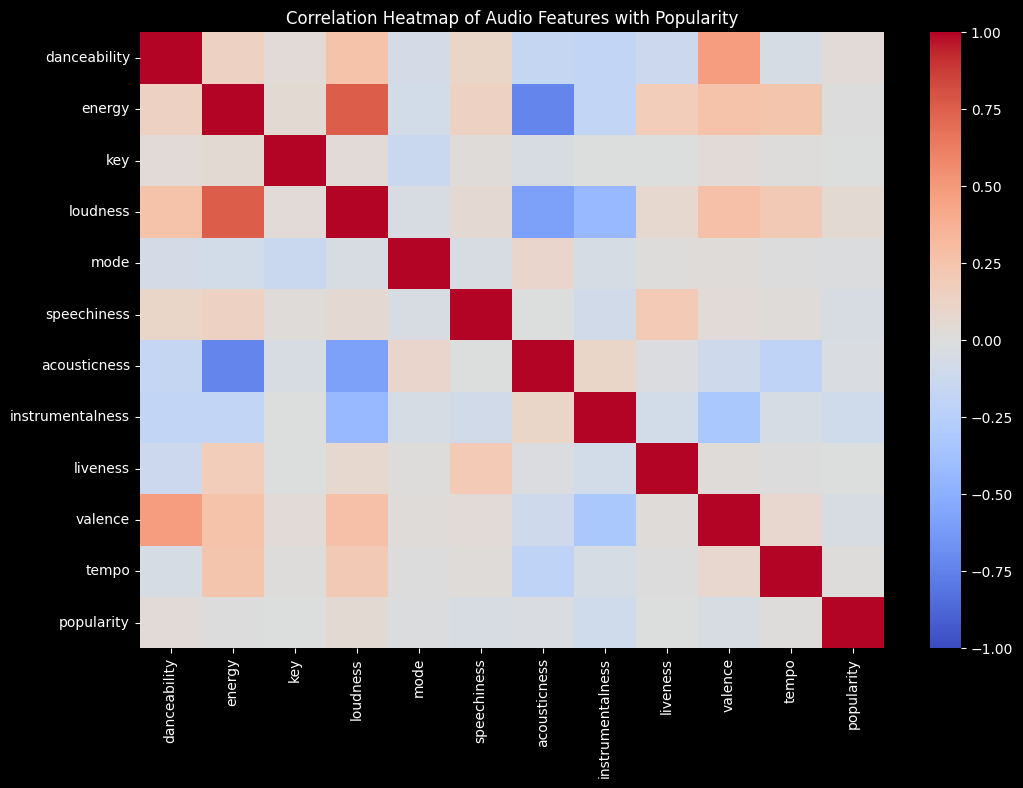

In [13]:
corr_matrix = df[audio_features + ['popularity']].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap of Audio Features with Popularity')
plt.show()


#### 2.10 Top 20 Most Viral Artists

/var/folders/60/_h9xnrx50j5c1tm68xggnhm00000gn/T/ipykernel_28594/1742298451.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/60/_h9xnrx50j5c1tm68xggnhm00000gn/T/ipykernel_28594/1742298451.py:31: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/60/_h9xnrx50j5c1tm68xggnhm00000gn/T/ipykernel_28594/1742298451.py:31: UserWarning: Glyph 29246 (\N{CJK UNIFIED IDEOGRAPH-723E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/60/_h9xnrx50j5c1tm68xggnhm00000gn/T/ipykernel_28594/1742298451.py:31: UserWarning: Glyph 23459 (\N{CJK UNIFIED IDEOGRAPH-5BA3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Gly

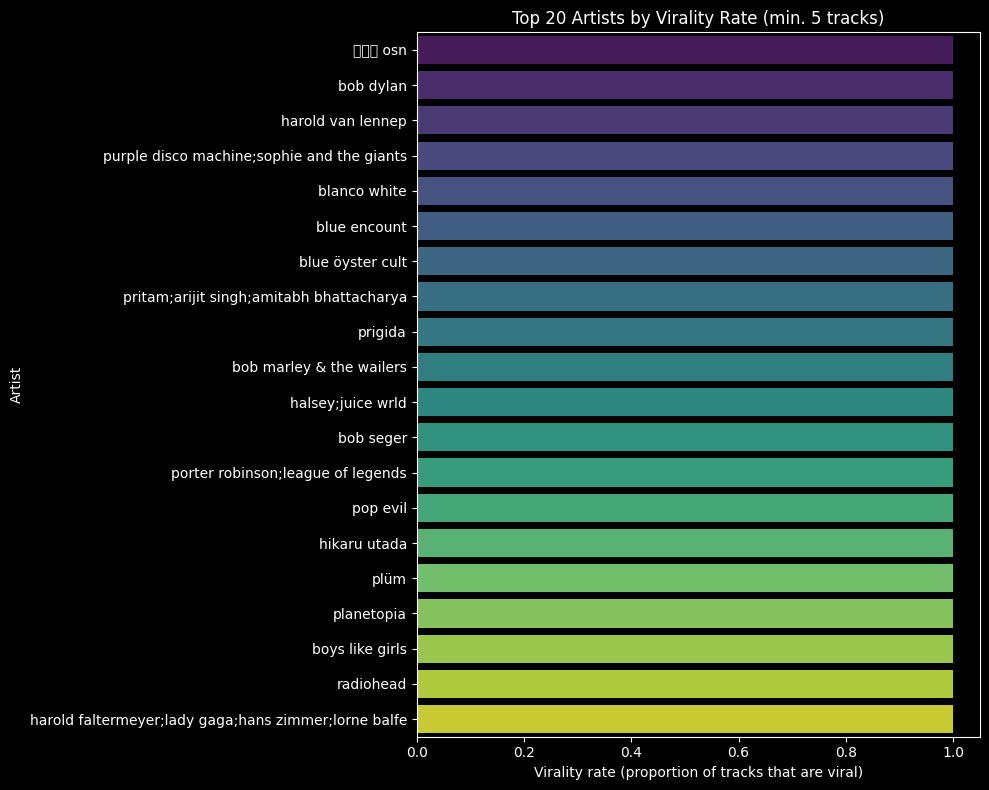

In [14]:
# Compute artist-level virality rate with minimum track count
artist_stats = (
    df.groupby('artists')
    .agg(
        n_tracks=('track_id', 'count'),
        virality_rate=('viral', 'mean')
    )
)

# Filter to artists with at least 5 tracks
artist_stats = artist_stats[artist_stats['n_tracks'] >= 5]

# Top 20 by virality rate
top20_artists = (
    artist_stats
    .sort_values("virality_rate", ascending=False)
    .head(20)
    .reset_index()
)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top20_artists,
    y="artists",
    x="virality_rate",
    palette="viridis"
)
plt.xlabel("Virality rate (proportion of tracks that are viral)")
plt.ylabel("Artist")
plt.title("Top 20 Artists by Virality Rate (min. 5 tracks)")
plt.tight_layout()
plt.show()

#### 2.11 Correlation Scatters Against Popularity

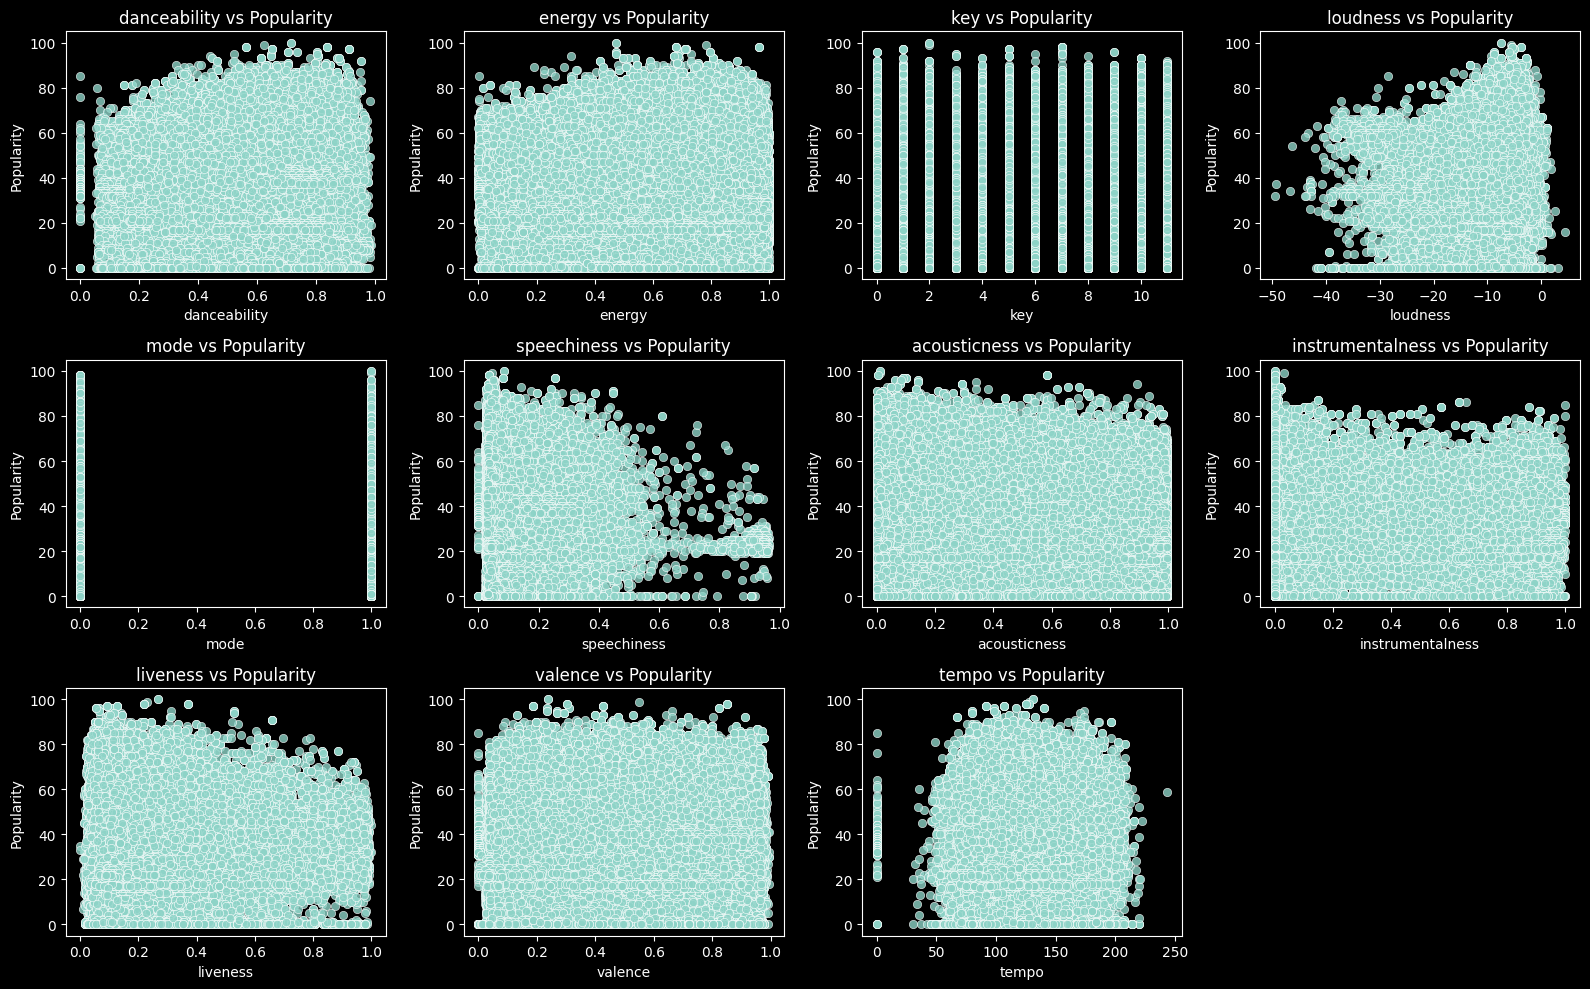

In [15]:
# For each audio feature, plot against popularity
fig, axes = plt.subplots(n_rows, m_cols, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    ax = axes[i]
    sns.scatterplot(x=feature, y='popularity', data=df, ax=ax, alpha=0.8)
    ax.set_title(f'{feature} vs Popularity')
    ax.set_xlabel(feature)
    ax.set_ylabel('Popularity')

# Hide any unused subplots (if features < n_rows * m_cols)
for j in range(len(audio_features), n_rows * m_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### 2.12 Point-Biserial Correlation Bar Chart

In [16]:
dropped_df = pd.read_parquet(os.path.join(PROCESSED_DATA_PATH, SPOTIFY_DROPPED))

print(dropped_df.columns)

Index(['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre', 'viral'],
      dtype='str')


In [17]:
# Correlation with viral
popularity_correlation = (
    dropped_df.select_dtypes(include=[np.number])
      .corr()['viral']
      .drop('viral')
)

# Convert to list
pop_corr_list = popularity_correlation.values.tolist()
# Absolute value
pop_corr_list_abs = [abs(ele) for ele in pop_corr_list]

In [18]:
def average(l) -> float:
    """
    Calculate the average of a list

    Args:
        l (list): List of numbers

    Returns:
        float: Average of the list
    """
    return sum(l) / len(l)

# Average correlation
pop_corr_list_abs_avg = average(pop_corr_list_abs)

In [19]:
# Convert to dataframe
pop_corr_df = popularity_correlation.to_frame()

# Add absolute value of correlation
pop_corr_df['viral_abs'] = abs(pop_corr_df['viral'])

# Select features with correlation greater than average
pop_corr_abv = pop_corr_df[(pop_corr_df['viral_abs'] > pop_corr_list_abs_avg)]

# Sort by absolute value of correlation
pop_corr_abv = pop_corr_abv.sort_values(by=['viral_abs'], ascending=False)

pop_corr_abv.head()

,viral,viral_abs
liveness,-0.086908,0.086908
instrumentalness,-0.081801,0.081801
danceability,0.052040,0.052040
speechiness,-0.049383,0.049383
duration_ms,-0.040975,0.040975


/var/folders/60/_h9xnrx50j5c1tm68xggnhm00000gn/T/ipykernel_28594/1279138627.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


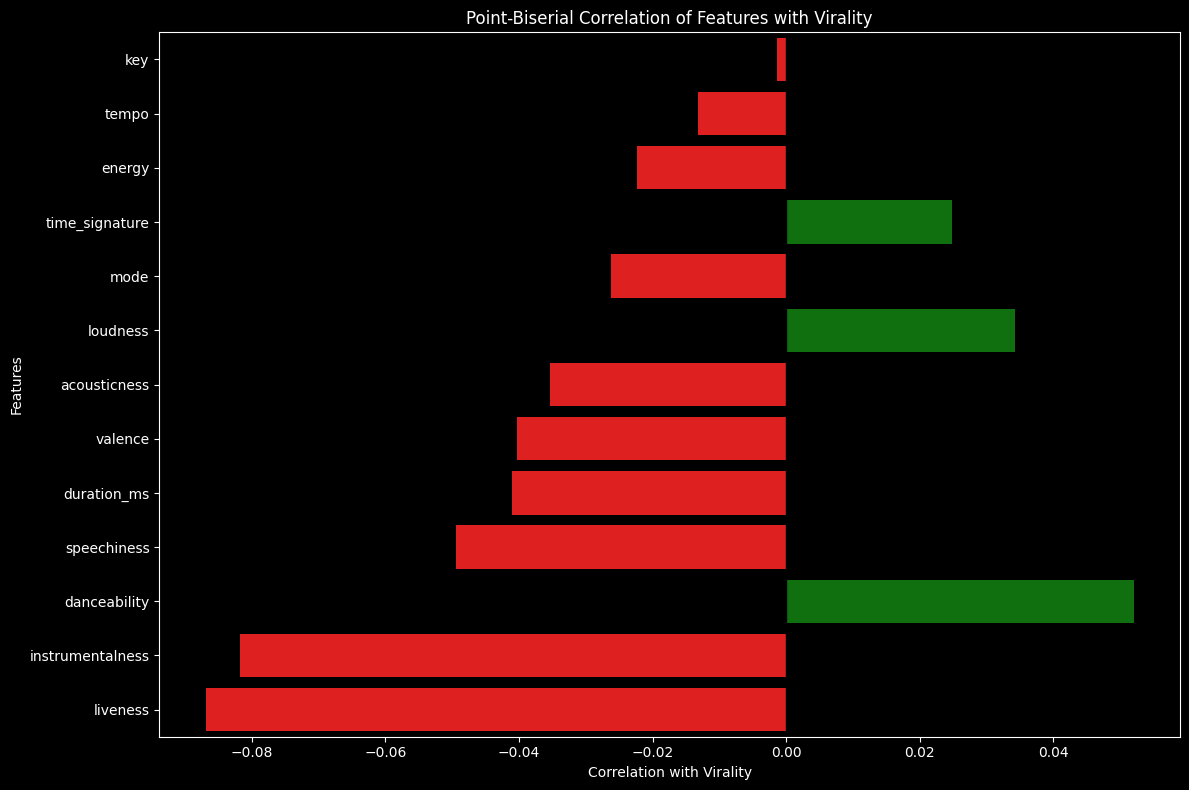

In [20]:
corr_plot_df = (
    pop_corr_df
    .sort_values('viral_abs', ascending=True)
)

plot_df = corr_plot_df.reset_index()
feature_col = plot_df.columns[0]

# Color positive vs negative correlations
colors = plot_df['viral'].apply(lambda x: 'green' if x > 0 else 'red')

plt.figure(figsize=(12, 8))
sns.barplot(
    data=plot_df,
    x='viral',
    y=feature_col,
    palette=list(colors),
)

plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Correlation with Virality')
plt.ylabel('Features')
plt.title('Point-Biserial Correlation of Features with Virality')
plt.tight_layout()
plt.show()

#### 2.13 Pairplot of Top 4 Features Coloured by Virality

In [21]:
top4_features = (
    pop_corr_df
    .sort_values('viral_abs', ascending=False)
    .head(4)
    .index
    .tolist()
)

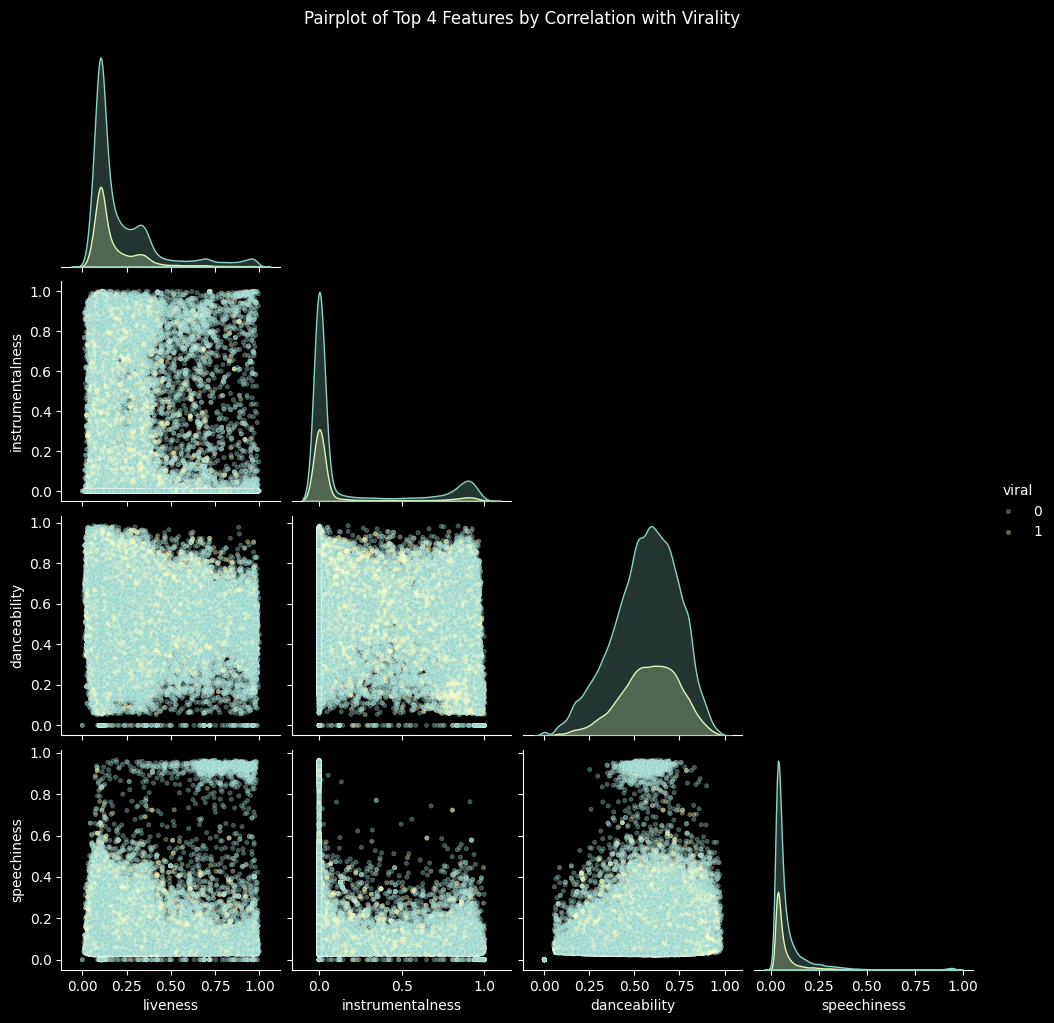

In [22]:
sns.pairplot(
    df[top4_features + ['viral']],
    hue='viral',
    corner=True,
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 10}
)

plt.suptitle('Pairplot of Top 4 Features by Correlation with Virality', y=1.02)
plt.show()

#### 2.14 Explicit vs. Non-Explicit Virality Rate

In [23]:
explicit_virality = (
    df.groupby('explicit')['viral']
    .mean()
    .reset_index()
)

explicit_virality['explicit'] = explicit_virality['explicit'].map({False: 'Non-explicit', True: 'Explicit'})

/var/folders/60/_h9xnrx50j5c1tm68xggnhm00000gn/T/ipykernel_28594/1118342806.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


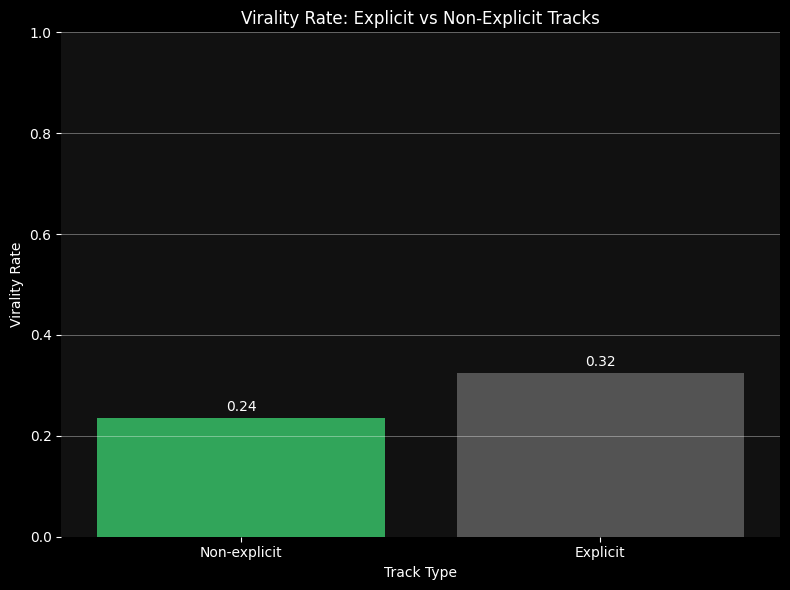

In [24]:
SPOTIFY_GREEN = "#1DB954"

plt.style.use("dark_background")

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=explicit_virality,
    x="explicit",
    y="viral",
    palette=[SPOTIFY_GREEN, "#535353"]  # Spotify green + dark grey
)

# Labels / title
ax.set_xlabel("Track Type", color="white")
ax.set_ylabel("Virality Rate", color="white")
ax.set_title("Virality Rate: Explicit vs Non-Explicit Tracks", color="white")
ax.set_ylim(0, 1)

# Tick colors
ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

# Soften axes: hide spines
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

# Soft grid on y only
ax.grid(False)
ax.grid(True, axis="y", color="#ffffff", alpha=0.5, linewidth=0.5)

ax.set_facecolor("#111111")

# --- Add value labels on bars ---
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.2f}",                       # or f"{height*100:.1f}%" for percent
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        color="white",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

#### 2.16 UMAP of Projection of Audio Features

In [25]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import umap

SPOTIFY_GREEN = "#1DB954"

features = audio_features
X = df[features].values
y = df["viral"].values

# Standardise features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    random_state=42,
)
X_umap = reducer.fit_transform(X_scaled)

umap_df = pd.DataFrame({
    "umap_1": X_umap[:, 0],
    "umap_2": X_umap[:, 1],
    "viral": y
})

/Users/vancence/Desktop/viral-content-predictor/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


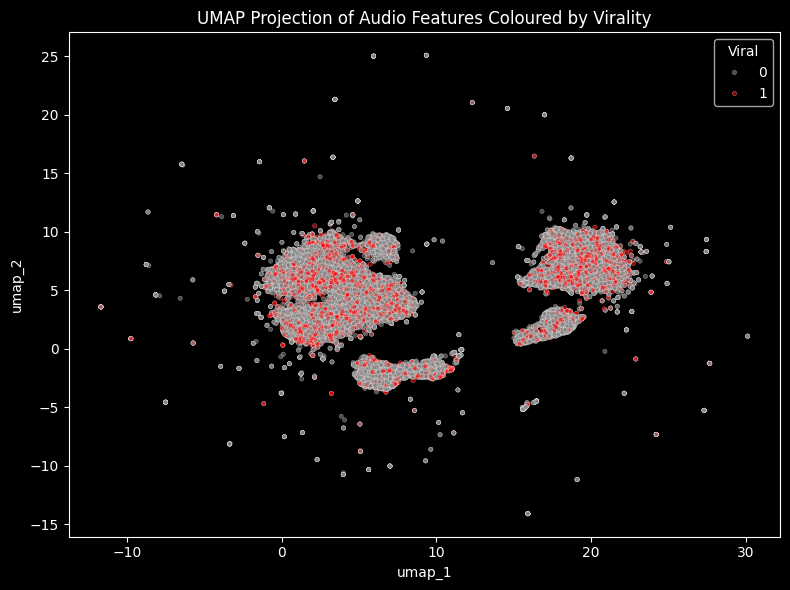

In [27]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=umap_df.sample(min(len(umap_df), 20000), random_state=42),
    x="umap_1",
    y="umap_2",
    hue="viral",
    palette={0: "grey", 1: "red"},
    alpha=0.6,
    s=10
)
plt.title("UMAP Projection of Audio Features Coloured by Virality")
plt.legend(title="Viral")
plt.tight_layout()
plt.show()

#### 2.15 t-SNE Projection of Audio Features

In [28]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

SPOTIFY_GREEN = "#1DB954"

features = audio_features
X = df[features].values
y = df["viral"].values

# Standardise features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run t-SNE (subsample if needed for speed)
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42,
    init="pca",
)
X_embedded = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame({
    "tsne_1": X_embedded[:, 0],
    "tsne_2": X_embedded[:, 1],
    "viral": y
})

plt.style.use("dark_background")